# Sky localization maps

In [2]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
from astropy.utils.data import get_pkg_data_filename
from astropy.io import fits
%matplotlib inline

## 1. Load a LIGO/Virgo Flat HEALPix Sky Map 
Example: S251112cm

In [3]:
# Read the map
m, header = hp.read_map('bayestar.fits', h=True, verbose=False)
header = dict(header)
print(f"Nside = {header['NSIDE']}, Ordering = {header['ORDERING']}")
print(f"Number of pixels = {len(m):,}")

Nside = 512, Ordering = NESTED
Number of pixels = 3,145,728


/var/folders/5q/zf85wh2d0sxgdd55ws_1kk94pzxs0q/T/ipykernel_59417/4120211818.py:2: HealpyDeprecationWarning: "verbose" was deprecated in version 1.15.0 and will be removed in a future version. 
  m, header = hp.read_map('bayestar.fits', h=True, verbose=False)


In [4]:
m

array([1.61449317e-13, 1.65103416e-13, 3.80432441e-13, ...,
       2.62669660e-13, 2.28974739e-13, 2.48964114e-13], dtype='>f8')

## 2. Understanding HEALPix Map Orderings

HEALPix maps can be stored in two different orderings:

- **RING ordering**: Pixels are arranged in horizontal rings of constant latitude, numbered from north to south pole
- **NESTED ordering**: Pixels follow a hierarchical quad-tree structure, where nearby pixels have nearby indices. **Best for computation, indexing, and hierarchical methods**


In [5]:
nside = hp.get_nside(m)        # or header['NSIDE']
npix = hp.nside2npix(nside)
print(f"Nside: {nside}")
print(f"Total pixels on the sky: {npix:,}")
print(f"Pixel area: {hp.nside2pixarea(nside, degrees=True):.4f} deg²")

Nside: 512
Total pixels on the sky: 3,145,728
Pixel area: 0.0131 deg²


$$N_{\text{pix}} = 12 \, \text{NSIDE}^2$$

## 3. Visualize the Sky Map (Mollweide Projection)

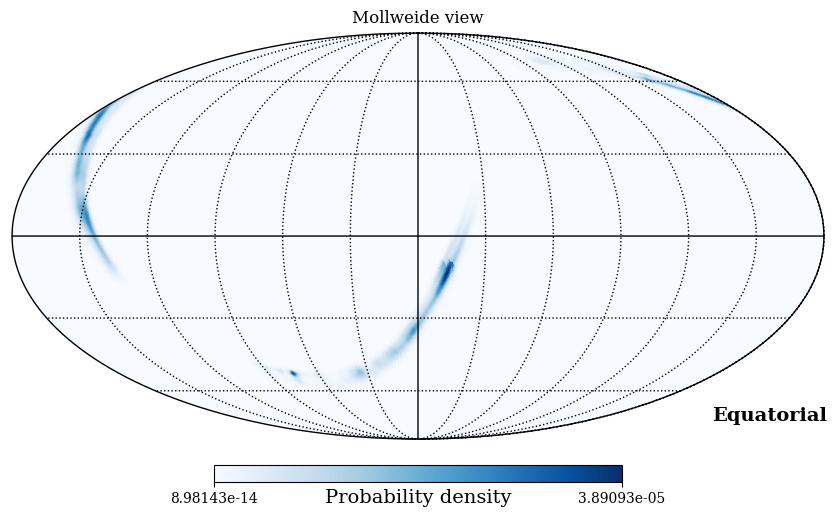

In [6]:
hp.mollview(m, unit="Probability density", coord='C', cmap='Blues')
hp.graticule()
plt.show()

### Careful about rotated axes!! Zero RA point is at the center of the map

## 4. Find the Highest-Probability Pixel & Convert to Sky Coordinates

In [7]:
ipix_max = np.argmax(m)
theta, phi = hp.pix2ang(nside, ipix_max)
ra_deg = np.degrees(phi)
dec_deg = 90 - np.degrees(theta)

print(f"Highest probability pixel index: {ipix_max}")
print(f"RA, Dec = {ra_deg:.4f}°, {dec_deg:.4f}°")

Highest probability pixel index: 1940405
RA, Dec = 346.8164°, -13.4781°


## 5. Compute Credible Levels (50%, 90%, etc.)

In [8]:
# Sort pixels by probability density (descending)
sorted_prob = np.sort(m)[::-1]

# Cumulative probability
cumsum = np.cumsum(sorted_prob)
cumsum /= cumsum[-1]  # normalize to 1

print(f"Number of pixels in 90% region: {np.count_nonzero(cumsum <= 0.90)}")
print(f"The area of the 90% credible region is {np.count_nonzero(cumsum <= 0.90) * hp.nside2pixarea(nside, degrees=True):.4f} deg²")

Number of pixels in 90% region: 93049
The area of the 90% credible region is 1220.2412 deg²


In [9]:
def get_credible_level(ra, dec, skymap_data, nside):
    """
    Get the credible level for a given RA and Dec position.
    
    Parameters:
    ra: Right Ascension in degrees
    dec: Declination in degrees
    skymap_data: HEALPix probability map
    nside: HEALPix nside parameter
    
    Returns:
    Credible level as a percentage
    """
    # Convert RA, Dec to theta, phi
    theta_query = np.radians(90 - dec)
    phi_query = np.radians(ra)
    
    # Get pixel index
    ipix_query = hp.ang2pix(nside, theta_query, phi_query)
    
    # Get probability at this pixel
    prob_at_pixel = skymap_data[ipix_query]
    
    # Calculate credible level
    sorted_prob_desc = np.sort(skymap_data)[::-1]
    cumsum_prob = np.cumsum(sorted_prob_desc)
    cumsum_prob /= cumsum_prob[-1]

    # I ASSIGNED TO EACH PIXEL THE CREDIBLE LEVEL BASED ON ITS PROBABILITY DENSITY, AFTER SORTING
    
    # Find where this probability falls in the sorted array
    credible_level = cumsum_prob[sorted_prob_desc >= prob_at_pixel][-1] * 100
    
    return credible_level, prob_at_pixel

# Example usage: check the highest probability pixel
ra_test = 180
dec_test = 55
cl, prob = get_credible_level(ra_test, dec_test, m, nside)
print(f"RA={ra_test:.4f}°, Dec={dec_test:.4f}°")
print(f"Probability density: {prob:.6e}")
print(f"Credible level: {cl:.2f}%")

RA=180.0000°, Dec=55.0000°
Probability density: 6.402603e-06
Credible level: 73.88%


## 7. Downgrade to Lower Resolution

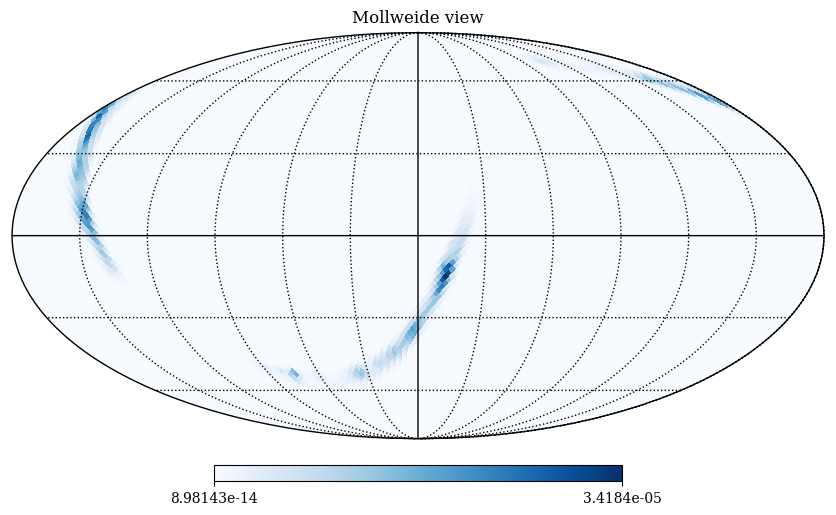

In [10]:
nside_low = 32
m_low = hp.ud_grade(m, nside_out=nside_low)  # averages probability density correctly

hp.mollview(m_low,cmap='Blues')
hp.graticule()
plt.show()

## 8. Integrated probability inside a circle

In [11]:
ra_test = 180
dec_test = 55
theta = np.radians(90 - dec_test)
phi = np.radians(ra_test)
radius = np.radians(5)  # example radius of 5 degrees
xyz = hp.ang2vec(theta, phi)
ipix_disc = hp.query_disc(nside, xyz, radius)
print(f"{m[ipix_disc].sum()*100:.2f}%")

4.84%


## 9. Integrated probability inside a polygon

In [12]:
# Convert polygon vertices from RA, Dec to Cartesian coordinates
# Create a square polygon centered at ra_test, dec_test with side 10 degrees
half_side = 5  # half of 10 degrees
vertices_radec = [[ra_test - half_side, dec_test - half_side], 
                  [ra_test + half_side, dec_test - half_side], 
                  [ra_test + half_side, dec_test + half_side], 
                  [ra_test - half_side, dec_test + half_side]]

xyz = np.array([hp.ang2vec(np.radians(90 - dec), np.radians(ra)) 
                for ra, dec in vertices_radec])
ipix_poly = hp.query_polygon(nside, xyz)
print(f"{m[ipix_poly].sum()*100:.2f}%")

3.39%


# Multi-order resolution maps

Each region of the sky is divide in sub-regions, and the process is done iteretively until it's reached a resolution of the same spatial scale of the variations of the map in that region of the sky. Coarser grid where the probability has a smoother change, finer where more information is contained

<img src="images/healpix-adaptive-mesh.svg" alt="Swift and Fermi mission comparison" width="300"/>

Then we have 2 info: the level of resolution of the sub-grid (given by nside) and the order of the pixel inside that sub-grid. This is compressed in a single index

$ uniq = ipix + 4 * nside^2 $   

In [13]:
from astropy.table import QTable
from astropy import units as u
import astropy_healpix as ah
import numpy as np

skymap = QTable.read('bayestar.multiorder.fits,1')

## Most Probable Sky Location

In [14]:
i = np.argmax(skymap['PROBDENSITY'])
uniq = skymap[i]['UNIQ']
level, ipix = ah.uniq_to_level_ipix(uniq)
nside = ah.level_to_nside(level)
nside

np.int64(512)

In [15]:
uniq = skymap[0]['UNIQ']
level, ipix = ah.uniq_to_level_ipix(uniq)
nside = ah.level_to_nside(level)
nside

np.int64(16)

This shows that around the peak of the probability map we have a high density of information, hence we require more resolution

In [16]:
ra, dec = ah.healpix_to_lonlat(ipix, nside, order='nested')
ra.deg, dec.deg

(np.float64(44.99999999999999), np.float64(2.388015463268777))

# Probability Density at a Known Position

In [17]:
ra = 180 * u.deg
dec = 55 * u.deg

In [18]:
max_level = 29
max_nside = ah.level_to_nside(max_level)
level, ipix = ah.uniq_to_level_ipix(skymap['UNIQ'])
index = ipix * (2**(max_level - level))**2

sorter = np.argsort(index)
match_ipix = ah.lonlat_to_healpix(ra, dec, max_nside, order='nested')
i = sorter[np.searchsorted(index, match_ipix, side='right', sorter=sorter)]
print('This is the probability density per deg^2:', skymap[i]['PROBDENSITY'].to_value(u.deg**-2))

This is the probability density per deg^2: 0.0005130987036434694


Notice that now since each pixel has different area, we can only report probability per unit area

# Credible level at a Known Position

In [20]:

import ligo.skymap.io.fits
from ligo.skymap.postprocess.util import find_greedy_credible_levels
from astropy.coordinates import SkyCoord

skymap_arr, _ = ligo.skymap.io.fits.read_sky_map('bayestar.multiorder.fits,1', nest=True)
cls = 100 * ligo.skymap.postprocess.util.find_greedy_credible_levels(skymap_arr)


theta = 0.5 * np.pi - np.deg2rad(-13.4780549)
phi = np.deg2rad(346.81640625)

# Query the multi-order map (handles variable resolution automatically)
ipix = hp.ang2pix(hp.get_nside(skymap_arr), theta, phi, nest=True)

print(f"Credible level : {cls[ipix]:.2f}%")

Credible level : 0.00%


# 90% region

In [21]:
#compute 90% area credible region from cls

#compute 90% area credible region from cls
a_90 = cls[cls <= 90]
n_pixels_90 = len(a_90)
area_90 = n_pixels_90 * hp.nside2pixarea(hp.get_nside(skymap_arr), degrees=True)
print(f"Number of pixels in 90% credible region: {n_pixels_90:,}")
print(f"Area of 90% credible region: {area_90:.2f} deg²")

Number of pixels in 90% credible region: 93,049
Area of 90% credible region: 1220.24 deg²


# Probability inside a circle

In [22]:
ra_test = 180
dec_test = 55
theta = np.radians(90 - dec_test)
phi = np.radians(ra_test)
radius = np.radians(5)  # example radius of 5 degrees
xyz = hp.ang2vec(theta, phi)
ipix_disc = hp.query_disc(hp.get_nside(skymap_arr), xyz, radius)
print(f"{m[ipix_disc].sum()*100:.2f}%")

4.84%


# Let's plot the skymap with credible contours

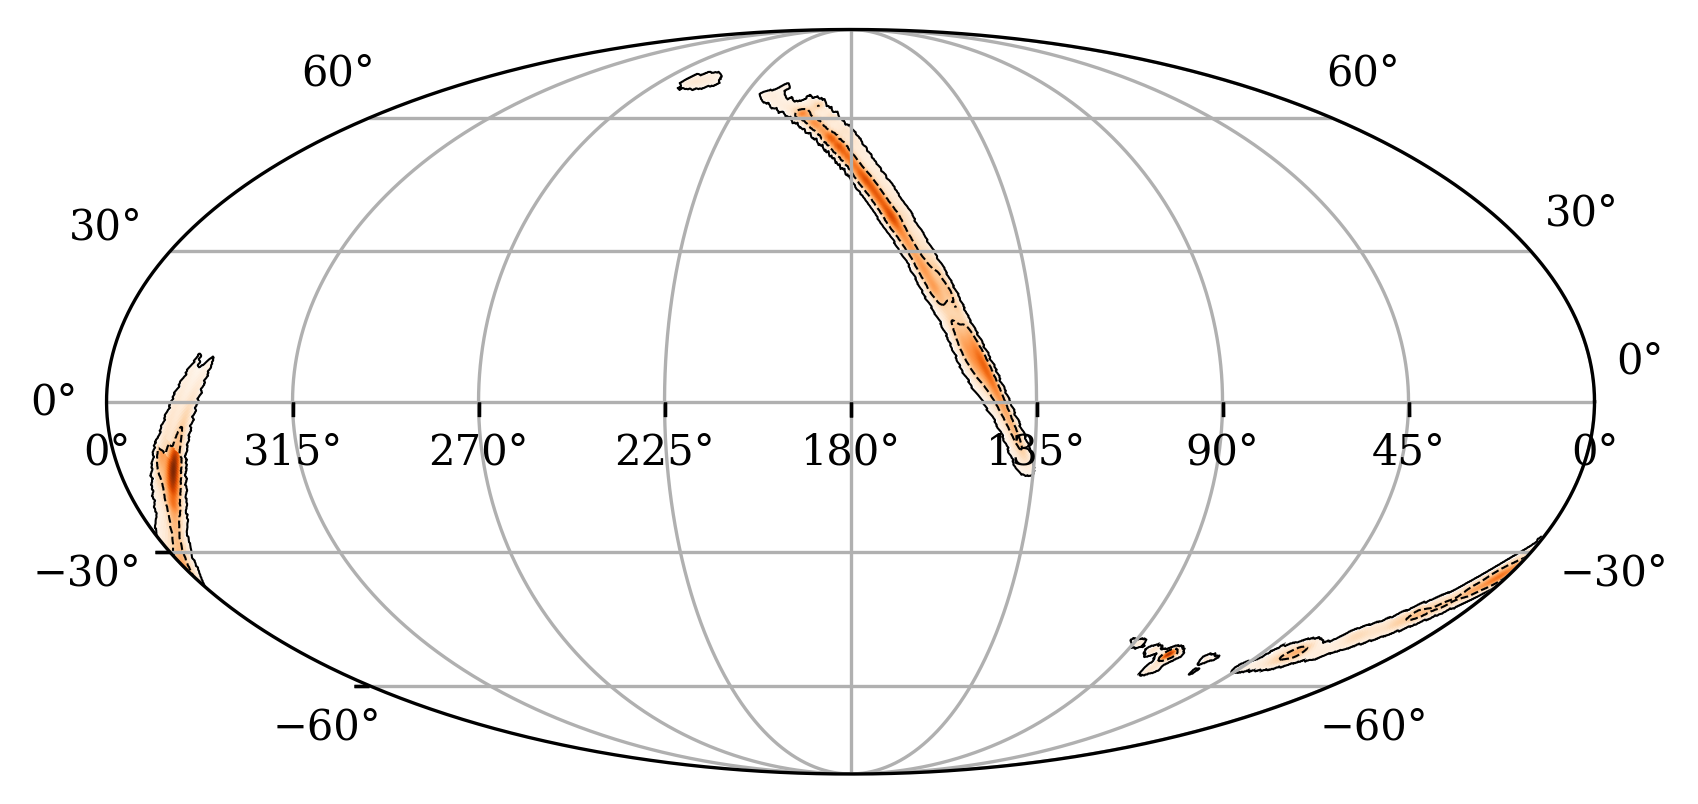

In [23]:
import ligo.skymap.io.fits
import ligo.skymap.postprocess.util
import numpy as np
import matplotlib.pyplot as pp
from matplotlib.colors import LogNorm
from matplotlib import cm
import ligo.skymap.plot

skymap, _ = ligo.skymap.io.fits.read_sky_map('bayestar.fits', nest = True) # NEST = True ensures that the order is rearranged properly, both for flat and multi-order maps

fig = pp.figure(dpi=300)
ax = pp.axes(projection='astro degrees mollweide')
ax.grid()


cls = 100 * ligo.skymap.postprocess.util.find_greedy_credible_levels(skymap)

skymap[cls > 90] = np.nan
skymap[skymap == 0] = np.nan

ax.imshow_hpx((skymap, 'ICRS'), nested=True, cmap=cm.Oranges)
ax.contour_hpx((cls, 'ICRS'), nested=True, colors='black', levels=(50, 90), zorder=1, linestyles=['dashed', 'solid'], linewidths=0.5)

pp.show()

# Zoom

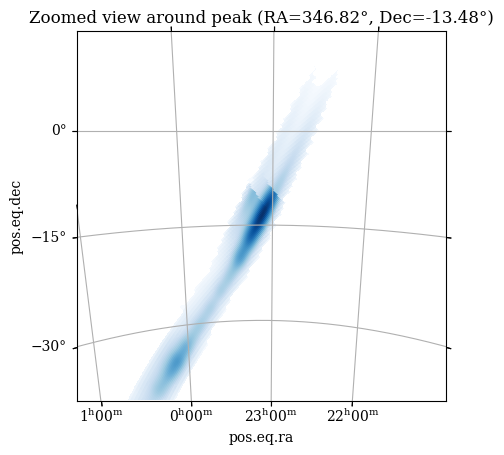

In [24]:
# Use the peak location from earlier
# Use the peak location from earlier
ax = plt.axes(projection='astro zoom',
              center=f'{ra_deg:.4f}d {dec_deg:.4f}d', radius='30 deg')
ax.grid()
ax.imshow_hpx((skymap, 'ICRS'), nested=True, cmap='Blues')

plt.title(f'Zoomed view around peak (RA={ra_deg:.2f}°, Dec={dec_deg:.2f}°)')
plt.show()

# Going in distance

Once we fix the position in the sky, the conditional posterior on distance is well approximated by a Gaussian times a uniform-in-volume prior.

$p(D_L | \text{RA, Dec}) = \text{DISTNORM(RA,Dec)} \times \exp\Big[-\dfrac{(D_L - \text{DISTMU(RA,Dec)})^2}{2 \text{DISTSTD(RA,Dec)}^2}\Big]\times D_L^2$

Using RA=180.000 deg, Dec=75.000 deg
mu=131.59, sigma=38.64


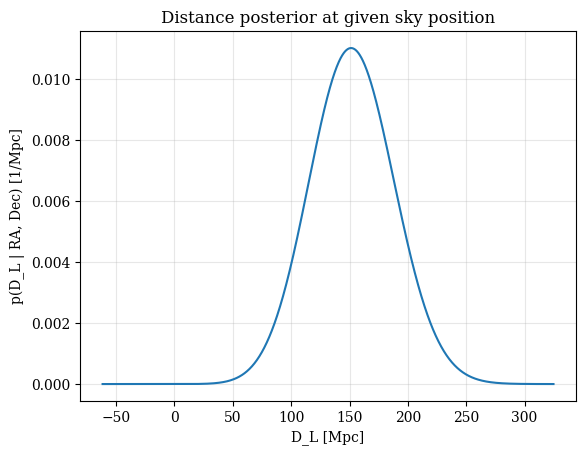

In [25]:

# Posterior p(D_L | RA, Dec) using BAYESTAR multi-order distance parameters
from scipy.stats import norm
import matplotlib
# Use mathtext with Computer Modern and avoid external TeX
matplotlib.rcParams['text.usetex'] = False
matplotlib.rcParams['mathtext.fontset'] = 'cm'
matplotlib.rcParams['font.family'] = 'serif'
matplotlib.rcParams['font.serif'] = ['DejaVu Serif', 'Nimbus Roman', 'Times New Roman', 'Times']

def distance_posterior(ra_deg, dec_deg, n=2000):
    # Load multi-order table without clobbering earlier 'skymap' array
    mo_table = QTable.read('bayestar.multiorder.fits,1')

    # Map (ra, dec) to the appropriate multi-order pixel
    level, ipix = ah.uniq_to_level_ipix(mo_table['UNIQ'])
    max_level = 29
    max_nside = ah.level_to_nside(max_level)
    index = ipix * (2**(max_level - level))**2
    sorter = np.argsort(index)

    ra_q = ra_deg if hasattr(ra_deg, 'unit') else ra_deg * u.deg
    dec_q = dec_deg if hasattr(dec_deg, 'unit') else dec_deg * u.deg
    match_ipix = ah.lonlat_to_healpix(ra_q, dec_q, max_nside, order='nested')
    i = sorter[np.searchsorted(index, match_ipix, side='right', sorter=sorter)]

    mu = mo_table[i]['DISTMU']         # [Mpc]
    sigma = mo_table[i]['DISTSIGMA']   # [Mpc]
    distnorm = mo_table[i]['DISTNORM']     # [1/Mpc^3]

    # Grid in distance (truncate at 0 and extend to ~5 sigma)
    dmin = mu - 5 * sigma
    dmax = (mu + 5 * sigma)
    D = np.linspace(dmin, dmax, n)

    # Conditional posterior p(D | Ω) ∝ DISTNORM * exp(-(D - mu)^2/(2σ^2)) * D^2
    p = D**2 * distnorm * norm(mu, sigma).pdf(D)

    # # Normalize numerically (should already be ~1)
    # Z = np.trapz(p.value, D.to_value(u.Mpc))
    # p /= Z

    return D, p, mu, sigma, norm, i


ra_query, dec_query = 180 * u.deg, 75 * u.deg

D, pD, mu, sigma, norm, idx = distance_posterior(ra_query, dec_query)

print(f"Using RA={ra_query.to_value(u.deg):.3f} deg, Dec={dec_query.to_value(u.deg):.3f} deg")
print(f"mu={mu.to_value(u.Mpc):.2f}, sigma={sigma.to_value(u.Mpc):.2f}")
# print(f"∫ p(D|Ω) dD ≈ {np.trapz(pD.value, D.to_value(u.Mpc)):.4f}")

plt.figure()
plt.plot(D, pD)
plt.xlabel('D_L [Mpc]')
plt.ylabel('p(D_L | RA, Dec) [1/Mpc]')
plt.title('Distance posterior at given sky position')
plt.grid(True, alpha=0.3)
plt.show()


Median distance: 93.94 Mpc
68% credible interval: [66.67, 124.24] Mpc
Sigma: 28.79 Mpc


/var/folders/5q/zf85wh2d0sxgdd55ws_1kk94pzxs0q/T/ipykernel_59417/1397576487.py:21: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  DL_marginal /= np.trapz(DL_marginal, D)


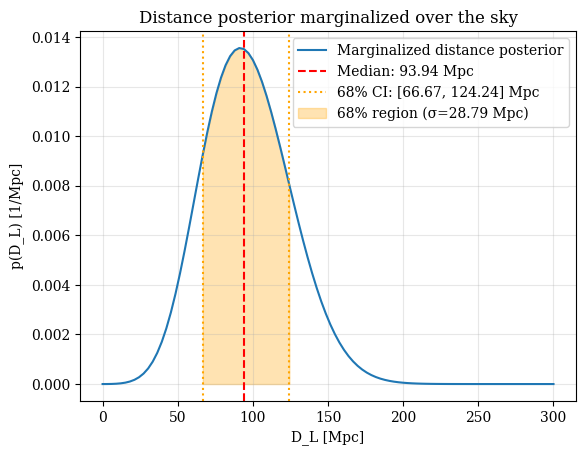

In [45]:
dmin = 0
dmax = 300
D = np.linspace(dmin, dmax, 100)

mo_table = QTable.read('bayestar.multiorder.fits,1')

level, ipix = ah.uniq_to_level_ipix(mo_table['UNIQ'])
pixel_area = ah.nside_to_pixel_area(ah.level_to_nside(level))

mu = mo_table['DISTMU'] .to_value(u.Mpc)      # [Mpc]
sigma = mo_table['DISTSIGMA'].to_value(u.Mpc)   # [Mpc]
distnorm = mo_table['DISTNORM'].to_value(1/u.Mpc**2)     # [1/Mpc^3]
prob_density = mo_table['PROBDENSITY'].to_value(1/u.sr)  # [1/sr]
pixel_area_sr = ah.nside_to_pixel_area(ah.level_to_nside(level))  # [sr]
prob_density *= pixel_area_sr.to_value(u.sr)  # Convert to total probability per pixel

# Compute marginalized distance posterior
DL_marginal = np.array([np.sum(prob_density * dd**2 * distnorm * norm(mu, sigma).pdf(dd)) for dd in D])

# Normalize the posterior
DL_marginal /= np.trapz(DL_marginal, D)

# Compute cumulative distribution
cumulative = np.cumsum(DL_marginal)
cumulative /= cumulative[-1]

# Find median (50th percentile)
median_idx = np.searchsorted(cumulative, 0.5)
median_distance = D[median_idx]

# Find 68% credible interval (16th and 84th percentiles)
lower_idx = np.searchsorted(cumulative, 0.16)
upper_idx = np.searchsorted(cumulative, 0.84)
lower_distance = D[lower_idx]
upper_distance = D[upper_idx]

# Compute sigma (half of the 68% credible interval width)
sigma_distance = (upper_distance - lower_distance) / 2

print(f"Median distance: {median_distance:.2f} Mpc")
print(f"68% credible interval: [{lower_distance:.2f}, {upper_distance:.2f}] Mpc")
print(f"Sigma: {sigma_distance:.2f} Mpc")

plt.figure()
plt.plot(D, DL_marginal, label='Marginalized distance posterior')
plt.axvline(median_distance, color='red', linestyle='--', label=f'Median: {median_distance:.2f} Mpc')
plt.axvline(lower_distance, color='orange', linestyle=':', label=f'68% CI: [{lower_distance:.2f}, {upper_distance:.2f}] Mpc')
plt.axvline(upper_distance, color='orange', linestyle=':')
plt.fill_between(D, 0, DL_marginal, where=(D >= lower_distance) & (D <= upper_distance), 
                 alpha=0.3, color='orange', label=f'68% region (σ={sigma_distance:.2f} Mpc)')
plt.xlabel('D_L [Mpc]')
plt.ylabel('p(D_L) [1/Mpc]')
plt.title('Distance posterior marginalized over the sky')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## Probability density per unit volume

In [49]:
mo_table = QTable.read('bayestar.multiorder.fits,1')

# Map (ra, dec) to the appropriate multi-order pixel
level, ipix = ah.uniq_to_level_ipix(mo_table['UNIQ'])
max_level = 29
max_nside = ah.level_to_nside(max_level)
index = ipix * (2**(max_level - level))**2
sorter = np.argsort(index)

ra_q = 180 * u.deg
dec_q = 55 * u.deg
d_test = 100 * u.Mpc

match_ipix = ah.lonlat_to_healpix(ra_q, dec_q, max_nside, order='nested')
i = sorter[np.searchsorted(index, match_ipix, side='right', sorter=sorter)]

level, ipix = ah.uniq_to_level_ipix(mo_table['UNIQ'])
pixel_area = ah.nside_to_pixel_area(ah.level_to_nside(level))

mu = mo_table['DISTMU'][i].to_value(u.Mpc)      # [Mpc]
sigma = mo_table['DISTSIGMA'][i].to_value(u.Mpc)   # [Mpc]
distnorm = mo_table['DISTNORM'][i].to_value(1/u.Mpc**2)     # [1/Mpc^3]
prob_density = mo_table['PROBDENSITY'][i].to_value(1/u.sr)  # [1/sr]
pixel_area_sr = ah.nside_to_pixel_area(ah.level_to_nside(level))[i].to_value(u.sr)  # [sr]


dv = prob_density * distnorm * norm(mu, sigma).pdf(d_test.to_value(u.Mpc)) / pixel_area_sr  # [1/Mpc]

dv

np.float64(0.03605645277666179)

What I am doing if instead of doing for pixel [i], I do

In [51]:
mu = mo_table['DISTMU'].to_value(u.Mpc)      # [Mpc]
sigma = mo_table['DISTSIGMA'].to_value(u.Mpc)   # [Mpc]
distnorm = mo_table['DISTNORM'].to_value(1/u.Mpc**2)     # [1/Mpc^3]
prob_density = mo_table['PROBDENSITY'].to_value(1/u.sr)  # [1/sr]
pixel_area_sr = ah.nside_to_pixel_area(ah.level_to_nside(level)).to_value(u.sr)  # [sr]


dv = prob_density * distnorm * norm(mu, sigma).pdf(d_test.to_value(u.Mpc)) / pixel_area_sr  # [1/Mpc]

dv

array([1.01367530e-09, 6.51252901e-10, 7.88960341e-10, ...,
       3.69863327e+00, 3.72964624e+00, 3.70715344e+00])

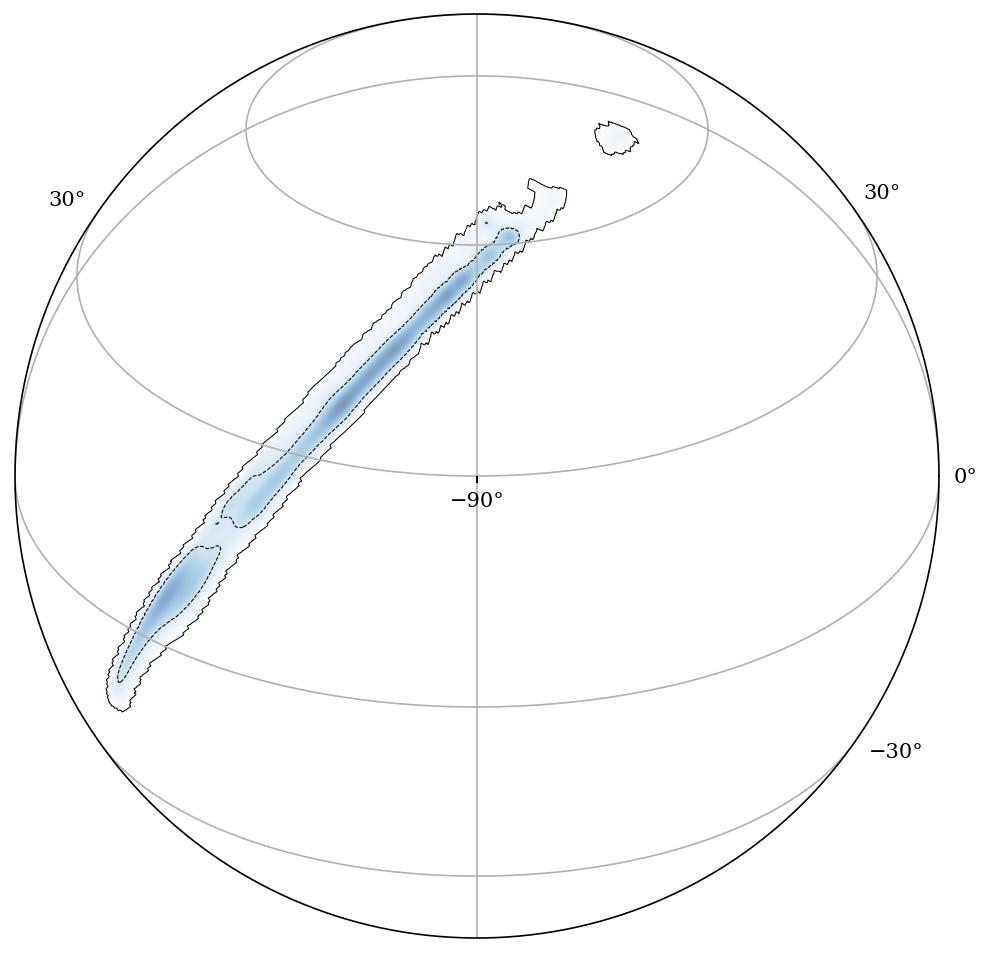

In [117]:
# Plot on skymap
fig = plt.figure(figsize=(12, 8), dpi=150)
ax = plt.axes(projection='geo globe', center='-90d 30d')
ax.grid()

# Plot the skymap
ax.imshow_hpx((skymap, 'ICRS'), nested=True, cmap='Blues', alpha=0.5)
ax.contour_hpx((cls, 'ICRS'), nested=True, colors='black', 
               levels=(50, 90), zorder=1, linestyles=['dashed', 'solid'], 
               linewidths=0.5)


Using HEALPix nside=8 for radius 5°
Target spacing: 8.660° (sqrt(3) × radius)
Actual pixel spacing: 7.329°
Total pixels (circle centers): 768
Selected 60 circles covering 89.90% of probability
(out of 768 total candidate circles)
Selected 60 circles covering 89.90% of probability
(out of 768 total candidate circles)


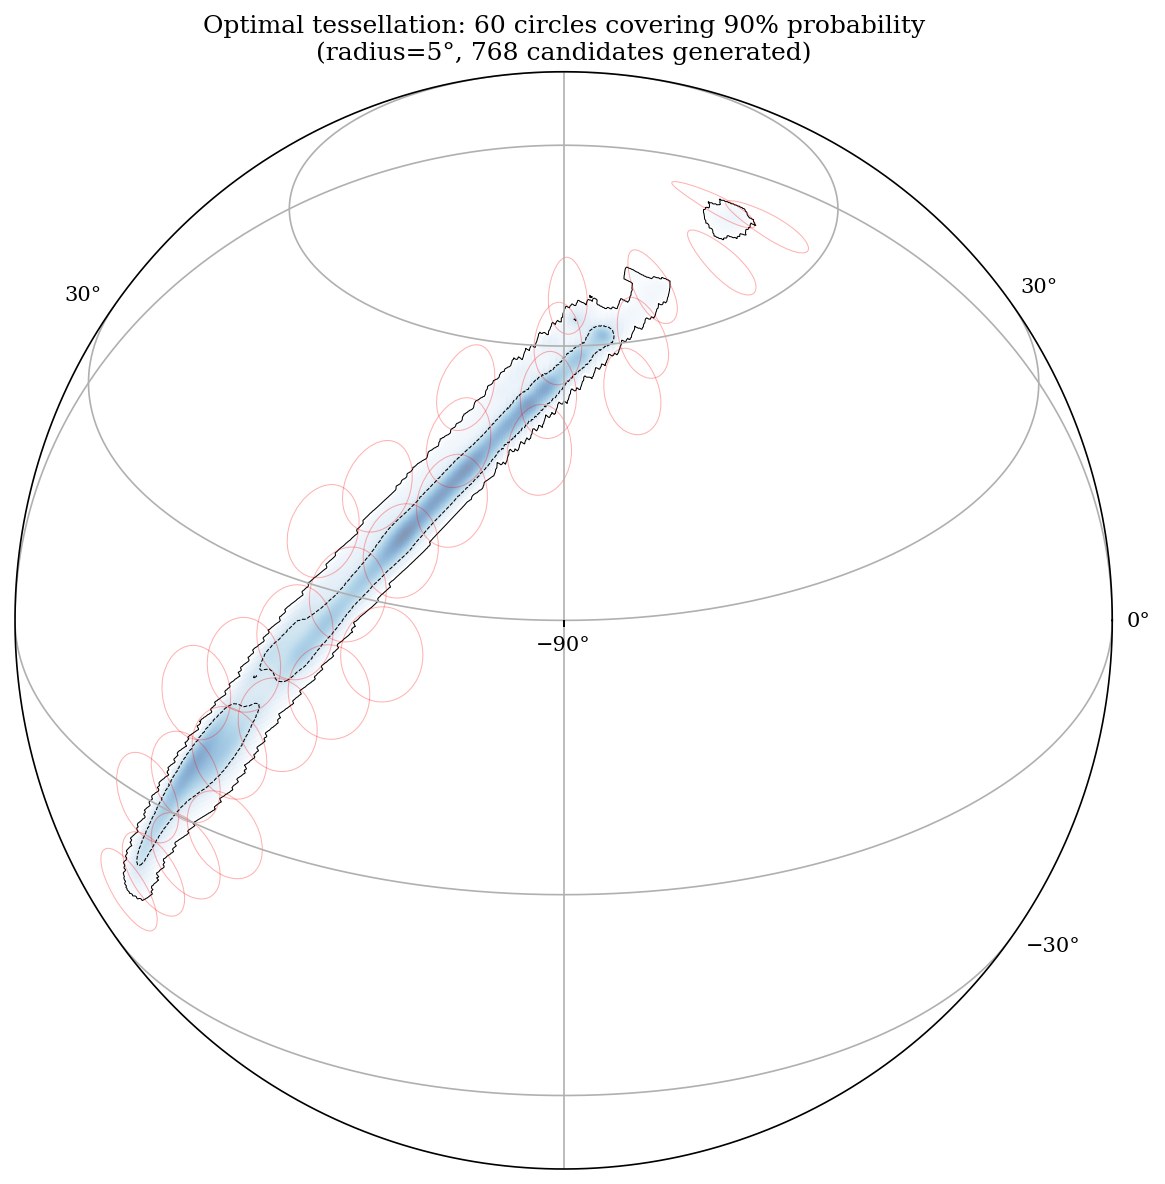

In [118]:
import numpy as np
import healpy as hp
from matplotlib.patches import Circle
from matplotlib.collections import PatchCollection

# Generate hexagonal tessellation of circles across the sky
import matplotlib.pyplot as plt
import ligo.skymap.plot
from scipy.spatial import ConvexHull

def normalize(v):
    return v / np.linalg.norm(v, axis=-1, keepdims=True)

def midpoint(a, b):
    return normalize((a + b) / 2)

def subdivide_triangle(v0, v1, v2, depth):
    """
    Recursively subdivide a triangle on the unit sphere.
    Returns a list of vertices on the sphere.
    """
    if depth == 0:
        return [v0, v1, v2]
    
    # midpoints of edges
    a = midpoint(v0, v1)
    b = midpoint(v1, v2)
    c = midpoint(v2, v0)
    
    # subdivide 4 smaller triangles
    vertices = []
    vertices += subdivide_triangle(v0, a, c, depth-1)
    vertices += subdivide_triangle(a, v1, b, depth-1)
    vertices += subdivide_triangle(c, b, v2, depth-1)
    vertices += subdivide_triangle(a, b, c, depth-1)
    
    return vertices

def geodesic_circle_centers(r_deg):
    """
    Generate circle centers on the sphere using HEALPix grid for optimal uniform coverage.
    This ensures uniform coverage even at the poles using HEALPix's equal-area pixelization.
    
    The spacing between centers is optimized for hexagonal close packing:
    d = sqrt(3) * r for maximum coverage with minimum overlap
    """
    r_rad = np.deg2rad(r_deg)
    
    # For optimal hexagonal packing: spacing = sqrt(3) * radius
    target_spacing = np.sqrt(3) * r_rad
    
    # Calculate required HEALPix nside
    # HEALPix pixel spacing (angular resolution) ≈ sqrt(4π / (12*nside²))
    # We want this to equal our target spacing
    pixel_area = target_spacing**2
    nside = int(np.ceil(np.sqrt(4 * np.pi / (12 * pixel_area))))
    
    # Ensure nside is a power of 2 for efficiency
    nside = 2**int(np.ceil(np.log2(nside)))
    
    npix = hp.nside2npix(nside)
    actual_spacing = np.rad2deg(np.sqrt(4 * np.pi / npix))
    
    print(f"Using HEALPix nside={nside} for radius {r_deg}°")
    print(f"Target spacing: {np.rad2deg(target_spacing):.3f}° (sqrt(3) × radius)")
    print(f"Actual pixel spacing: {actual_spacing:.3f}°")
    print(f"Total pixels (circle centers): {npix:,}")
    
    # Get all HEALPix pixel centers in nested ordering
    # Nested ordering provides better locality and hierarchical structure
    ipix = np.arange(npix)
    theta, phi = hp.pix2ang(nside, ipix, nest=True)
    
    # Convert to RA, Dec
    dec = 90 - np.rad2deg(theta)
    ra = np.rad2deg(phi)
    
    return ra, dec

# Example usage
r_circle = 5  # degrees
ra_centers, dec_centers = geodesic_circle_centers(r_circle)


# Plot on skymap
fig = plt.figure(figsize=(12, 8), dpi=150)
ax = plt.axes(projection='geo globe', center='-90d 30d')
ax.grid()

# Plot the skymap
ax.imshow_hpx((skymap, 'ICRS'), nested=True, cmap='Blues', alpha=0.5)
ax.contour_hpx((cls, 'ICRS'), nested=True, colors='black', 
               levels=(50, 90), zorder=1, linestyles=['dashed', 'solid'], 
               linewidths=0.5)

# Greedy algorithm to select minimum circles covering 90% probability
# Step 1: Calculate total probability in each circle (without marking as covered yet)
circle_data = []
for ra_c, dec_c in zip(ra_centers, dec_centers):
    theta_c = np.radians(90 - dec_c)
    phi_c = np.radians(ra_c)
    xyz_c = hp.ang2vec(theta_c, phi_c)
    
    # Get pixels within the circle
    ipix_disc = hp.query_disc(hp.npix2nside(len(skymap)), xyz_c, 
                               np.radians(r_circle), nest=True)
    
    # Total probability in this circle (initial ranking)
    total_prob = np.nansum(skymap[ipix_disc])
    circle_data.append((ra_c, dec_c, ipix_disc, total_prob))

# Step 2: Greedy selection - pick circles that add most uncovered probability
selected_circles = []
covered_pixels = set()
cumulative_prob = 0.0
target_prob = 0.9

while cumulative_prob < target_prob and circle_data:
    # Find circle that adds most uncovered probability
    best_idx = -1
    best_new_prob = 0.0
    
    for idx, (ra_c, dec_c, ipix_disc, _) in enumerate(circle_data):
        # Calculate uncovered probability in this circle
        uncovered_pixels = [pix for pix in ipix_disc if pix not in covered_pixels]
        new_prob = np.nansum(skymap[uncovered_pixels]) if uncovered_pixels else 0.0
        
        if new_prob > best_new_prob:
            best_new_prob = new_prob
            best_idx = idx
    
    # If no circle adds probability, stop
    if best_idx == -1 or best_new_prob == 0:
        break
    
    # Add best circle to selection
    ra_c, dec_c, ipix_disc, _ = circle_data[best_idx]
    selected_circles.append((ra_c, dec_c, best_new_prob))
    
    # Mark pixels as covered
    covered_pixels.update(ipix_disc)
    cumulative_prob += best_new_prob
    
    # Remove selected circle from candidates
    circle_data.pop(best_idx)

print(f"Selected {len(selected_circles)} circles covering {cumulative_prob:.2%} of probability")
print(f"(out of {len(ra_centers)} total candidate circles)")

# Plot only the selected circles that contribute to 90% coverage
circles_plotted = 0
for ra_c, dec_c, prob in selected_circles:
    # Skip circles that would extend beyond valid declination range
    if abs(dec_c) + r_circle > 90:
        continue
    
    circle = Circle(
        (ra_c, dec_c),
        r_circle,
        edgecolor='red',
        facecolor='none',
        linewidth=0.5,
        alpha=0.3,
        transform=ax.get_transform('icrs')
    )
    ax.add_patch(circle)
    circles_plotted += 1

plt.title(f'Optimal tessellation: {circles_plotted} circles covering 90% probability\n(radius={r_circle}°, {len(ra_centers)} candidates generated)')
plt.tight_layout()
plt.show()